# Final Project: [ชื่อโครงงาน]
> 1145 201 คณิตศาสตร์สำหรับวิทยาการข้อมูล | Semester 1/2568

**กลุ่ม:** [ระบุชื่อสมาชิกและรหัสนักศึกษา]
- สมาชิกที่ 1: นาย ธนวรรธ ทองตื้อ (68114540258)
- สมาชิกที่ 2: ชื่อ-นามสกุล (รหัส)

**Dataset:** (https://www.kaggle.com/datasets/sergionefedov/college-major-roi)

**Problem Statement:** [อธิบาย 2-3 ประโยคว่าปัญหาคืออะไร ทำไมถึงสนใจ dataset นี้]

---

| CLO | ส่วนที่ครอบคลุม | Status |
|-----|----------------|--------|
| CLO1 (Linear Algebra) | Part 2 | ⬜ |
| CLO2 (Statistical Learning) | Part 3 | ⬜ |
| CLO3 (Regression/Classification) | Part 4 | ⬜ |
| CLO4 (Model Selection) | Part 5 | ⬜ |

In [45]:
# ─── Import libraries ──────────────────────────────────────────────
# TODO: เพิ่ม/ลบ libraries ตามที่โครงงานของคุณต้องใช้
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
print('Ready.')

Ready.


---
## Part 1: Dataset Overview และ EDA เบื้องต้น

ในส่วนนี้ให้โหลด dataset, แสดง basic statistics, และทำ EDA เบื้องต้นเพื่อเข้าใจข้อมูลก่อนวิเคราะห์

**สิ่งที่ต้องทำ:**
- โหลด dataset และแสดง shape, dtypes, missing values
- แสดง descriptive statistics ด้วย `.describe()`
- Plot distribution ของ target variable
- Plot correlation heatmap หรือ scatter matrix

In [46]:
# ─── โหลด Dataset ────────────────────────────────────────────────
# วัตถุประสงค์: เข้าใจโครงสร้างของข้อมูลก่อนวิเคราะห์
from sys import displayhook

# TODO: แทนที่ด้วย path หรือวิธีโหลด dataset ของคุณ
df = pd.read_csv('college_major_roi.csv')

columns_to_drop = [
    'grad_id', 'net_roi_usd', 'added_earnings_10yr_usd', 
    'hs_baseline_10yr_usd', 'roi_pct', 'positive_roi', 'high_roi', "major", "institution_tier"
]
df_clean = df.drop(columns=columns_to_drop)

# แสดงข้อมูลพื้นฐาน
print(f'Shape: {df_clean.shape}')
print(f"\ntypes:\n{df_clean.dtypes}")
print(f'\nColumns: {df_clean.columns.tolist()}')
print(f'\nMissing values:\n{df_clean.isnull().sum()}')
print(f'\nStats:')

df_only_number = df_clean[["institution_selectivity_pctile", "gpa", "net_cost_usd", "debt_usd", "earnings_10yr_usd"]]
display(df_only_number.describe())
df_clean.head()

Shape: (30000, 9)

types:
major_category                        str
institution_selectivity_pctile      int64
gpa                               float64
had_internship                      int64
completed_on_time                   int64
region                                str
net_cost_usd                        int64
debt_usd                            int64
earnings_10yr_usd                   int64
dtype: object

Columns: ['major_category', 'institution_selectivity_pctile', 'gpa', 'had_internship', 'completed_on_time', 'region', 'net_cost_usd', 'debt_usd', 'earnings_10yr_usd']

Missing values:
major_category                    0
institution_selectivity_pctile    0
gpa                               0
had_internship                    0
completed_on_time                 0
region                            0
net_cost_usd                      0
debt_usd                          0
earnings_10yr_usd                 0
dtype: int64

Stats:


,institution_selectivity_pctile,gpa,net_cost_usd,debt_usd,earnings_10yr_usd
count,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04
mean,55.086067,3.093337,88621.496667,38498.063333,7.153680e+05
std,18.593708,0.439060,33576.903160,37801.748200,2.977847e+05
min,16.000000,1.500000,28500.000000,0.000000,2.723000e+05
25%,42.000000,2.790000,65500.000000,0.000000,4.835000e+05
50%,55.000000,3.100000,81000.000000,38700.000000,6.458000e+05
75%,68.000000,3.400000,103600.000000,62300.000000,8.717000e+05
max,102.000000,4.000000,352900.000000,331700.000000,3.245500e+06


,major_category,institution_selectivity_pctile,gpa,had_internship,completed_on_time,region,net_cost_usd,debt_usd,earnings_10yr_usd
0,STEM,52,2.58,0,0,south,144400,0,512700
1,business,61,2.58,0,1,northeast,57400,0,687500
2,STEM,78,3.14,1,1,northeast,65100,39600,994700
3,business,77,3.04,0,1,midwest,105800,81300,597100
4,business,100,3.81,0,0,south,219200,93500,558600


In [47]:
def inspect_categorical_columns(dataframe, columns=None):
    if columns is None:
        columns = dataframe.select_dtypes(include=['object', 'category']).columns.tolist()
    
    for col in columns:
        unique_vals = dataframe[col].unique()
        n_unique = dataframe[col].nunique()
        
        print(f"\nคอลัมน์: '{col}'")
        print(f"ค่าที่มี: {list(unique_vals)}")
        
        print(" จำนวนข้อมูลในแต่ละกลุ่ม:")
        counts = dataframe[col].value_counts()
        for val, count in counts.items():
            pct = (count / len(dataframe)) * 100
            print(f"   - {val:<25} : {count:>5} คน ({pct:.2f}%)")
        print("-" * 50)

cat_cols = ['major_category', 'region']
inspect_categorical_columns(df_clean, columns=cat_cols)



คอลัมน์: 'major_category'
ค่าที่มี: ['STEM', 'business', 'social_science', 'education', 'health', 'arts', 'humanities']
 จำนวนข้อมูลในแต่ละกลุ่ม:
   - STEM                      :  9904 คน (33.01%)
   - business                  :  8361 คน (27.87%)
   - social_science            :  5989 คน (19.96%)
   - health                    :  1589 คน (5.30%)
   - humanities                :  1410 คน (4.70%)
   - arts                      :  1395 คน (4.65%)
   - education                 :  1352 คน (4.51%)
--------------------------------------------------

คอลัมน์: 'region'
ค่าที่มี: ['south', 'northeast', 'midwest', 'west']
 จำนวนข้อมูลในแต่ละกลุ่ม:
   - south                     :  9488 คน (31.63%)
   - northeast                 :  7512 คน (25.04%)
   - midwest                   :  6655 คน (22.18%)
   - west                      :  6345 คน (21.15%)
--------------------------------------------------


In [48]:
# ทดลองตรวจสอบสภาวะ multicollinearity ระหว่าง institution_tier กับ institution selectivity_pctile
new_df = pd.read_csv('college_major_roi.csv')

tier_summary = new_df.groupby('institution_tier')['institution_selectivity_pctile'].agg(['min', 'mean', 'max'])
print("📊 ช่วงคะแนนความยากในการสอบเข้าของแต่ละระดับมหาวิทยาลัย:")
display(tier_summary)

# แปลง Tier เป็นลำดับตัวเลขชั่วคราวเพื่อหาค่า Correlation
tier_map = {'for_profit': 0, 'regional': 1, 'mid_tier': 2, 'top_public': 3, 'ivy_elite': 4}
tier_numeric = new_df['institution_tier'].map(tier_map)

# คำนวณค่าสหสัมพันธ์ (Pearson Correlation)
corr_value = tier_numeric.corr(new_df['institution_selectivity_pctile'])
print(f"\n🔍 ค่า Correlation ระหว่าง Tier กับ Selectivity Pctile = {corr_value:.4f}")

📊 ช่วงคะแนนความยากในการสอบเข้าของแต่ละระดับมหาวิทยาลัย:


,min,mean,max
institution_tier,,,
for_profit,16,21.934901,28
ivy_elite,90,96.105023,102
mid_tier,52,58.035192,64
regional,36,42.036203,48
top_public,68,73.995330,80



🔍 ค่า Correlation ระหว่าง Tier กับ Selectivity Pctile = 0.9768


ผลการวิเคราะห์: ค่า correlation สูงถึง ~0.98 (เกือบ 1.0) แสดงถึงภาวะ Multicollinearity รุนแรง
ข้อสรุป: เราจึงตัด 'institution_tier' ออก และเก็บ 'institution_selectivity_pctile' ไว้เพียงตัวเดียว

In [60]:
# ทำ One-Hot Encoding สำหรับ major_category และ region เพื่อแปลงข้อความให้เป็นตัวเลข (0 1) เพื่อให้โมเดล Regression คำนวณได้
df_encoded_for_graph = pd.get_dummies(df_clean, columns=['major_category', 'region'], drop_first=False, dtype=int)
df_encoded = pd.get_dummies(df_clean, columns=['major_category', 'region'], drop_first=True, dtype=int)
display(df_encoded.head())


,institution_selectivity_pctile,gpa,had_internship,completed_on_time,net_cost_usd,debt_usd,earnings_10yr_usd,major_category_arts,major_category_business,major_category_education,major_category_health,major_category_humanities,major_category_social_science,region_northeast,region_south,region_west
0,52,2.58,0,0,144400,0,512700,0,0,0,0,0,0,0,1,0
1,61,2.58,0,1,57400,0,687500,0,1,0,0,0,0,1,0,0
2,78,3.14,1,1,65100,39600,994700,0,0,0,0,0,0,1,0,0
3,77,3.04,0,1,105800,81300,597100,0,1,0,0,0,0,0,0,0
4,100,3.81,0,0,219200,93500,558600,0,1,0,0,0,0,0,1,0


In [61]:
# ─── Descriptive Statistics + Visualization ───────────────────────
# วัตถุประสงค์: ดูภาพรวมของข้อมูล

# TODO: เพิ่ม code สำหรับ:
df_only_number.describe()

,institution_selectivity_pctile,gpa,net_cost_usd,debt_usd,earnings_10yr_usd
count,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04
mean,55.086067,3.093337,88621.496667,38498.063333,7.153680e+05
std,18.593708,0.439060,33576.903160,37801.748200,2.977847e+05
min,16.000000,1.500000,28500.000000,0.000000,2.723000e+05
25%,42.000000,2.790000,65500.000000,0.000000,4.835000e+05
50%,55.000000,3.100000,81000.000000,38700.000000,6.458000e+05
75%,68.000000,3.400000,103600.000000,62300.000000,8.717000e+05
max,102.000000,4.000000,352900.000000,331700.000000,3.245500e+06


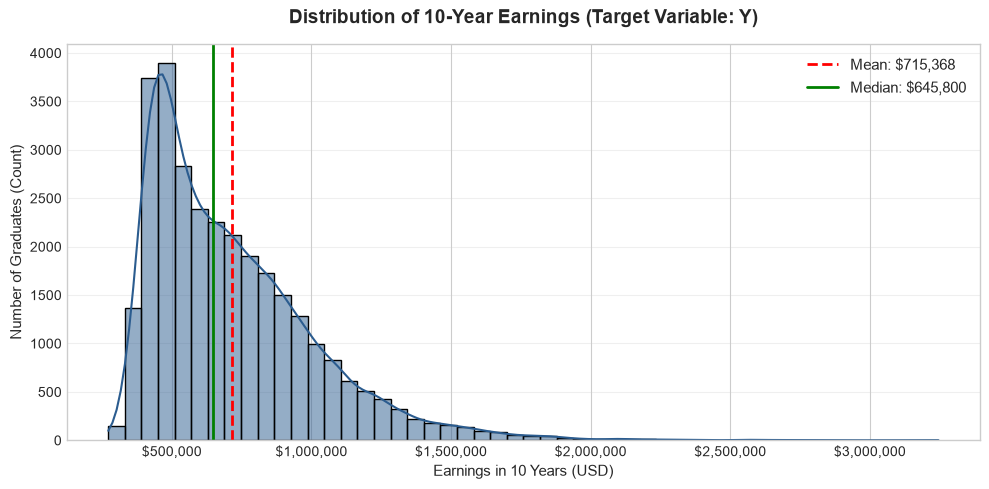

In [62]:
plt.figure(figsize=(10, 5))

# พล็อต Histogram และเส้น KDE
sns.histplot(df_clean['earnings_10yr_usd'], kde=True, bins=50, color='#2b5c8f')

# คำนวณค่าเฉลี่ยและมัธยฐาน
mean_val = df_clean['earnings_10yr_usd'].mean()
median_val = df_clean['earnings_10yr_usd'].median()

# วาดเส้น Mean และ Median
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: ${mean_val:,.0f}')
plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: ${median_val:,.0f}')

# ตกแต่งกราฟ
plt.title('Distribution of 10-Year Earnings (Target Variable: Y)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Earnings in 10 Years (USD)', fontsize=11)
plt.ylabel('Number of Graduates (Count)', fontsize=11)

# ปรับแกน X ให้อ่านเป็นหลักพัน/หลักล้านง่ายๆ (ใส่เครื่องหมาย comma)
plt.gca().xaxis.set_major_formatter('${x:,.0f}')
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

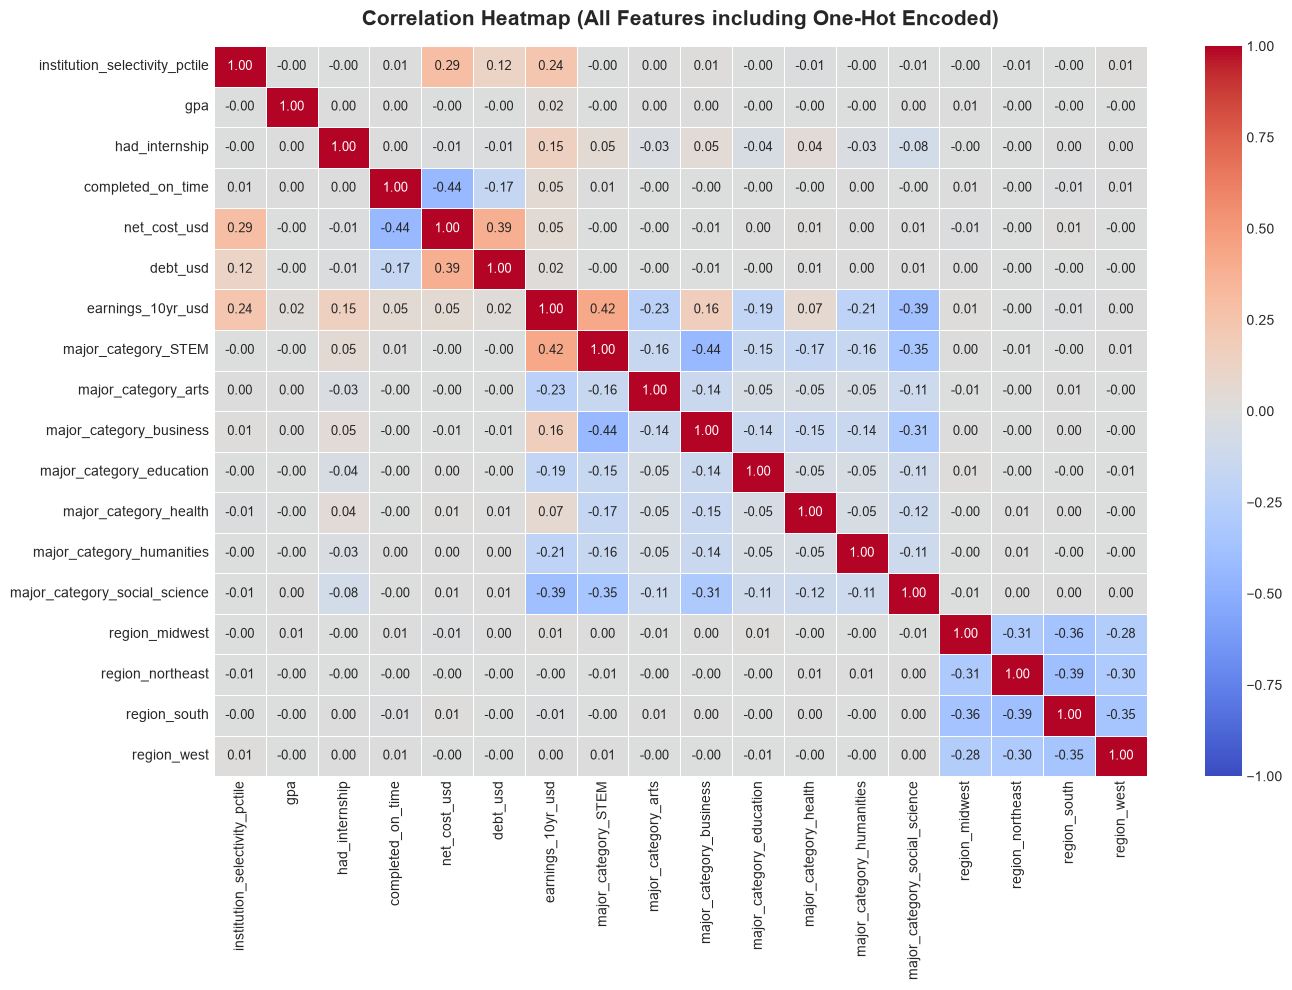

In [63]:
plt.figure(figsize=(14, 10))

# คำนวณ Correlation ของทุกคอลัมน์ใน df_encoded
corr_matrix_all = df_encoded_for_graph.corr()

# พล็อต Heatmap ทั้งหมด
sns.heatmap(
    corr_matrix_all, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    vmin=-1, vmax=1, 
    linewidths=0.5,
    annot_kws={"size": 9} # ปรับขนาดตัวเลขข้างในให้พอดี
)

plt.title('Correlation Heatmap (All Features including One-Hot Encoded)', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

---
## Part 2: CLO1 — Linear Algebra Analysis

ในส่วนนี้ให้ใช้ Linear Algebra เพื่อ analyze dataset

**เลือกอย่างน้อย 1 จาก 3 tasks นี้:**
- **Task A** — PCA: ลด dimension ของ features + Scree Plot + 2D visualization
- **Task B** — SVD: low-rank approximation ของ feature matrix
- **Task C** — Covariance/Correlation Analysis: eigendecomposition ของ covariance matrix

**คำอธิบาย:** [อธิบาย 2-3 ประโยคว่าทำไมถึงเลือก task นี้ และ insight ที่คาดว่าจะได้]

In [ ]:
# ─── CLO1: Linear Algebra Analysis ──────────────────────────────
# วัตถุประสงค์: [ระบุว่าทำอะไร — PCA / SVD / Covariance]

# TODO: เขียน code ที่นี่
# ตัวอย่างสำหรับ PCA:
# X = df[feature_cols].values
# X_centered = X - X.mean(axis=0)
# C = (1/(len(X)-1)) * X_centered.T @ X_centered
# eigenvalues, eigenvectors = np.linalg.eigh(C)
# ...
pass

**Insight จาก CLO1 Analysis:**
> [อธิบายสิ่งที่ค้นพบ — เช่น PC1 อธิบาย X% variance, features ไหน contribute มากที่สุด]

---
## Part 3: CLO2 — Statistical Learning

ในส่วนนี้ให้ทำ Statistical Analysis ที่เกี่ยวข้องกับ dataset

**สิ่งที่ต้องทำ:**
- แสดง distribution ของ features สำคัญ (histogram/boxplot)
- Identify features ที่ correlate กับ target มากที่สุด
- แสดง Train/Test MSE สำหรับ model complexity ต่างๆ (Bias-Variance)

**คำถาม:** dataset ของคุณเหมาะกับ Regression หรือ Classification? เพราะอะไร?

In [ ]:
# ─── CLO2: Statistical Analysis ───────────────────────────────────
# วัตถุประสงค์: เข้าใจ statistical properties ของ dataset

# TODO:
# 1. Plot distributions
# 2. Correlation analysis กับ target
# 3. แสดง U-curve ของ Train/Test MSE (polynomial degree หรือ model complexity)
pass

**Insight จาก CLO2 Analysis:**
> [อธิบาย: features สำคัญคืออะไร? distribution ของ target เป็นอย่างไร? optimal complexity อยู่ที่เท่าไหร่?]

---
## Part 4: CLO3 — Model Building

ในส่วนนี้ให้สร้าง Regression หรือ Classification model อย่างน้อย 2 models

**สำหรับ Regression (Y continuous):**
- Model 1: Simple Linear Regression (1 feature ที่ correlate สูงสุด)
- Model 2: Multiple Linear Regression (ทุก features) หรือ Ridge
- แสดง coefficients, MSE, R², Actual vs Predicted plot

**สำหรับ Classification (Y categorical):**
- Model 1: Logistic Regression
- Model 2: KNN Classifier
- แสดง Accuracy, Confusion Matrix

**Dataset ของกลุ่มเหมาะกับ:** ⬜ Regression  ⬜ Classification

In [ ]:
# ─── CLO3: Model 1 ─────────────────────────────────────────────────
# วัตถุประสงค์: [ระบุว่า Model 1 คืออะไร]

# TODO:
# X_train, X_test, y_train, y_test = train_test_split(...)
# model1 = ???
# model1.fit(X_train, y_train)
# ...
pass

In [ ]:
# ─── CLO3: Model 2 ─────────────────────────────────────────────────
# วัตถุประสงค์: [ระบุว่า Model 2 คืออะไร]

# TODO:
# model2 = ???
# ...
pass

**สรุป Model Comparison:**

| Model | Train Metric | Test Metric | รายละเอียด |
|-------|-------------|------------|----------|
| Model 1: ___ | | | |
| Model 2: ___ | | | |

**Insight:**
> [เปรียบเทียบ: Model ไหนดีกว่า? ทำไม? มี overfitting/underfitting ไหม?]

---
## Part 5: CLO4 — Model Selection

ในส่วนนี้ให้ใช้ Cross-Validation เพื่อเลือก model ที่ดีที่สุดอย่างเป็นธรรม

**สิ่งที่ต้องทำ:**
- เปรียบเทียบอย่างน้อย 3 models ด้วย 5-Fold Cross-Validation
- Plot bar chart ของ CV MSE (หรือ Accuracy สำหรับ Classification)
- สรุปว่า model ไหนดีที่สุดและทำไม

In [ ]:
# ─── CLO4: 5-Fold Cross-Validation ────────────────────────────────
# วัตถุประสงค์: เปรียบเทียบ models อย่างเป็นธรรมด้วย CV

# TODO:
# models = {
#     'Model 1': ???,
#     'Model 2': ???,
#     'Model 3': ???,
# }
#
# for name, model in models.items():
#     scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')
#     cv_mse = -scores.mean()
#     print(f'{name}: CV MSE = {cv_mse:.4f}')
pass

**Best Model จาก Cross-Validation:** [ระบุ]

**เหตุผล:**
> [อธิบาย: CV MSE ต่ำสุดคือเท่าไหร่? มี overfitting ไหม? เชื่อมกับ Bias-Variance อย่างไร?]

---
## Part 6: สรุปผลและ Data Story

**6.1 สรุปผลการวิเคราะห์:**
> [สรุป findings หลักจากแต่ละ CLO ใน 4-5 bullet points]
- CLO1: ...
- CLO2: ...
- CLO3: ...
- CLO4: ...

**6.2 Limitations:**
> [อะไรที่ทำไม่ได้หรือมีข้อจำกัด เช่น dataset เล็กเกินไป, missing values, features ไม่ครบ]

**6.3 ขั้นตอนต่อไป (Future Work):**
> [ถ้ามีเวลามากกว่านี้จะทำอะไรต่อ]

**6.4 Connection กับ Topics ในวิชา:**
> [เชื่อมกับ Week ต่างๆ ที่เรียนมา ว่า concept ไหนนำมาใช้จริงในโครงงานนี้]

---
**Acknowledgements:** [ขอบคุณแหล่งข้อมูล / tools / references ที่ใช้]